In [681]:
import numpy as np


class LogReg:
    def __init__(self, lr=0.1, C=1, num_iter=1000):
        self.lr = lr
        self.C = C
        self.num_iter = num_iter
        self.weights = np.array([])
        self.bias = 0
        self.losses = []

    def sigmoid_usual(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid(self, z):
        z = np.array(z, dtype=float)

        positive = z >= 0
        negative = ~positive

        out = np.empty_like(z, dtype=float)

        out[positive] = 1 / (1 + np.exp(-z[positive]))
        out[negative] = np.exp(z[negative]) / (1 + np.exp(z[negative]))

        return out

    def loss(self, probs, y, n):
        eps = 1e-15
        probs = np.clip(probs, eps, 1 - eps)

        loss = -(1 / n) * np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

        return loss

    def gradients(self, n, X, y, logits, metrics="neg_log_loss"):
        if metrics == "neg_log_loss":
            return {
                "weights": (1 / n) * np.matmul(X.T, (logits - y))
                + (1 / self.C) * self.weights,
                "bias": (1 / n) * sum(logits - y),
            }

    def params_renew(self, weights, bias, gradient_weights, gradient_bias):
        weights = weights.copy()  # to not change original weights

        weights -= np.dot(self.lr, gradient_weights)
        bias -= np.dot(self.lr, gradient_bias)
        return weights, bias

    def predict(self, X_test):
        probabilities = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        classes = (probabilities >= 0.5).astype(int)
        return classes

    def predict_proba(self, X_test):
        p1 = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        p0 = 1 - p1
        return np.vstack([p0, p1]).T

    def fit(self, X, y, epsilon=1e-6):
        prev_loss = float("inf")
        self.weights = np.zeros(X.shape[1])
        n = X.shape[0]

        for i in range(self.num_iter):
            logits = np.matmul(X, self.weights) + self.bias
            probs = self.sigmoid(logits)

            grads = self.gradients(n, X, y, probs)
            gradient_weights = grads["weights"]
            gradient_bias = grads["bias"]

            new_weights, new_bias = self.params_renew(
                self.weights, self.bias, gradient_weights, gradient_bias
            )

            loss = self.loss(probs, y, n)
            self.losses.append(loss)
            if abs(prev_loss - loss) < epsilon:
                print(f"Stopped on iteration {i}")
                break
            self.weights, self.bias = new_weights, new_bias
            prev_loss = loss

In [682]:
from sklearn.datasets import load_breast_cancer

np.set_printoptions(suppress=True)

early_stopping_value = 0.000001
num_iterations = 100000
C = 1

X, y = load_breast_cancer(return_X_y=True)

In [683]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y)
print(f"% class=1 in train: {sum(y_train) / len(y_train)}")
print(f"% class=1 in y_test: {sum(y_test) / len(y_test)}")

% class=1 in train: 0.626953125
% class=1 in y_test: 0.631578947368421


In [684]:
log_reg = LogReg(num_iter=num_iterations, C=C)
log_reg.fit(X_train, y_train)

print(f"Weights: {log_reg.weights}")
print(f"Bias: {log_reg.bias}")
predictions = log_reg.predict(X_test)
probs = log_reg.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(f"Logloss: {log_loss(y_test, probs)}")

Stopped on iteration 262
Weights: [-0.11582745 -0.07636736 -0.11571764 -0.10912571 -0.04910719 -0.06985791
 -0.09101759 -0.11595744 -0.04158618  0.02759565 -0.08303452  0.00415117
 -0.07570646 -0.07589654  0.01583528 -0.01073384 -0.00386631 -0.0427453
  0.01186139  0.02084181 -0.12626889 -0.09053834 -0.12383484 -0.11416281
 -0.07813997 -0.08178303 -0.09312165 -0.12601165 -0.07495963 -0.04276562]
Bias: 0.6058215606645422
Accuracy: 0.9298245614035088
Logloss: 0.2721393284549926


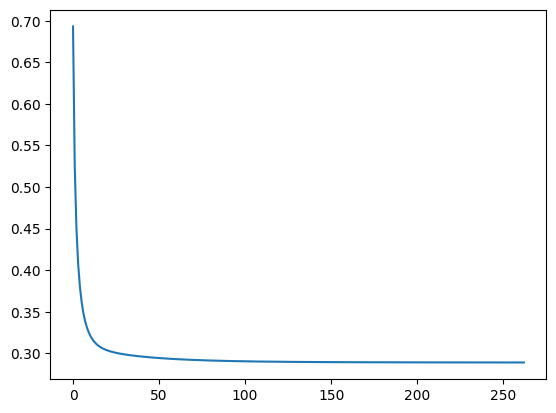

In [685]:
plt.plot(log_reg.losses)